In [1]:
import os

# force working directory to repo root
notebook_dir = os.path.dirname(os.path.abspath("day04_wall_detection.ipynb"))
root_dir = os.path.dirname(notebook_dir)
os.chdir(root_dir)

print(f"working directory: {os.getcwd()}")

working directory: c:\Users\Subramani Mokkala\Desktop\arc-agi3-research


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import arc_agi

load_dotenv()

arc = arc_agi.Arcade(arc_api_key=os.getenv("ARC_API_KEY"))
envs = arc.get_environments()

ACTION_UP = 1
ACTION_DOWN = 2
ACTION_LEFT = 3
ACTION_RIGHT = 4

def get_player_position(frame):
    frame = np.array(frame).squeeze()
    positions = np.argwhere(frame == 12)
    if len(positions) > 0:
        return positions.mean(axis=0)[:2]
    return None

def get_goal_position(frame):
    frame = np.array(frame).squeeze()
    positions = np.argwhere(frame == 9)
    if len(positions) > 0:
        top_half = positions[positions[:, 0] < 32]
        if len(top_half) > 0:
            return top_half.mean(axis=0)[:2]
    return None

print("connected, environments loaded:", len(envs))

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-06-15 15:29:15 | INFO | Successfully fetched 25 environment(s) from API
connected, environments loaded: 25


In [3]:
env = arc.make(game_id="ls20", save_recording=False)
obs = env.reset()

print("environment ready")
print(f"player position: {get_player_position(obs.frame)}")
print(f"goal position: {get_goal_position(obs.frame)}")
print(f"available actions: {obs.available_actions}")

2026-06-15 15:29:38 | INFO | Created new scorecard: ed16bb58-29b5-415b-8cc1-c436982a1322
2026-06-15 15:29:39 | INFO | Successfully fetched metadata for game ls20
2026-06-15 15:29:39 | INFO | Successfully loaded game class Ls20 from environment_files\ls20\9607627b\ls20.py
environment ready
player position: [45.5 36. ]
goal position: [11.83333333 36.16666667]
available actions: [1, 2, 3, 4]


In [4]:
def detect_wall(obs_before, obs_after):
    player_before = get_player_position(obs_before.frame)
    player_after = get_player_position(obs_after.frame)
    if player_before is None or player_after is None:
        return False
    return np.allclose(player_before, player_after, atol=1.0)

def choose_action(player, goal, blocked_actions, available_actions):
    candidates = [a for a in available_actions if a not in blocked_actions]
    if not candidates:
        candidates = available_actions

    row_diff = player[0] - goal[0]
    col_diff = player[1] - goal[1]

    if abs(row_diff) >= abs(col_diff):
        preferred = ACTION_UP if row_diff > 0 else ACTION_DOWN
        fallback = ACTION_LEFT if col_diff > 0 else ACTION_RIGHT
    else:
        preferred = ACTION_LEFT if col_diff > 0 else ACTION_RIGHT
        fallback = ACTION_UP if row_diff > 0 else ACTION_DOWN

    if preferred in candidates:
        return preferred
    elif fallback in candidates:
        return fallback
    else:
        return np.random.choice(candidates)

obs = env.reset()
step = 0
max_steps = 500
blocked_actions = set()
prev_player = None

print("starting wall-aware agent")
print(f"player: {get_player_position(obs.frame)}")
print(f"goal: {get_goal_position(obs.frame)}")

while obs.state.value == "NOT_FINISHED" and step < max_steps:
    player = get_player_position(obs.frame)
    goal = get_goal_position(obs.frame)

    if player is None or goal is None:
        action = np.random.choice(obs.available_actions)
        blocked_actions = set()
    else:
        if prev_player is not None and np.allclose(player, prev_player, atol=1.0):
            blocked_actions.add(last_action)
        else:
            blocked_actions = set()

        action = choose_action(player, goal, blocked_actions, obs.available_actions)

    prev_player = player
    last_action = action
    obs_after = env.step(action)

    if detect_wall(obs, obs_after):
        blocked_actions.add(action)

    obs = obs_after
    step += 1

    if step % 20 == 0:
        print(f"step {step} | levels: {obs.levels_completed} | player: {get_player_position(obs.frame)}")

print(f"\ngame ended after {step} steps")
print(f"final state: {obs.state.value}")
print(f"levels completed: {obs.levels_completed} / {obs.win_levels}")

starting wall-aware agent
player: [45.5 36. ]
goal: [11.83333333 36.16666667]
step 20 | levels: 0 | player: [15.5 36. ]
step 40 | levels: 0 | player: [15.5 36. ]
step 60 | levels: 0 | player: [15.5 36. ]
step 80 | levels: 0 | player: [15.5 36. ]
step 100 | levels: 0 | player: [20.5 36. ]
step 120 | levels: 0 | player: [20.5 36. ]

game ended after 129 steps
final state: GAME_OVER
levels completed: 0 / 7


player at: [20.5 36. ]


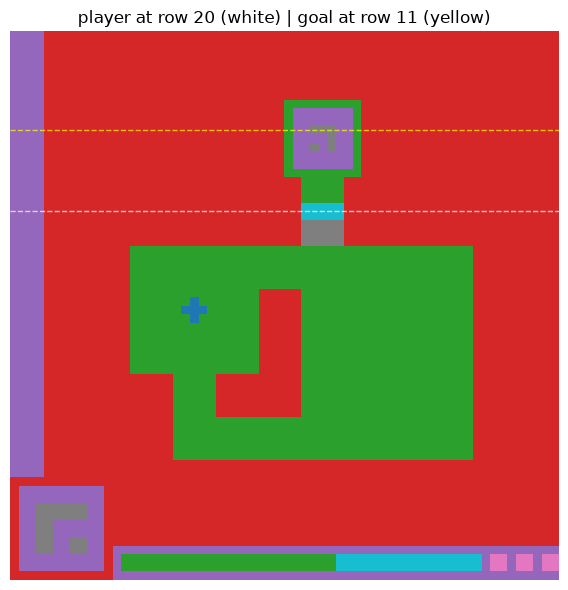


color values between player and goal:
  row 11: colors [3, 4, 5, 9]
  row 12: colors [3, 4, 5, 9]
  row 13: colors [3, 4, 5, 9]
  row 14: colors [3, 4, 5]
  row 15: colors [3, 4, 5]
  row 16: colors [3, 4, 5]
  row 17: colors [3, 4, 5]
  row 18: colors [3, 4, 5]
  row 19: colors [3, 4, 5]
  row 20: colors [4, 5, 12]


In [5]:
obs = env.reset()

# run until player reaches row 15
step = 0
while step < 25:
    player = get_player_position(obs.frame)
    goal = get_goal_position(obs.frame)
    if player is not None and goal is not None:
        action = choose_action(player, goal, set(), obs.available_actions)
    else:
        action = ACTION_UP
    obs = env.step(action)
    step += 1

frame = np.array(obs.frame).squeeze()
player = get_player_position(obs.frame)

print(f"player at: {player}")

# show the frame with player and goal marked
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(frame, cmap="tab10", vmin=0, vmax=12)
ax.axhline(y=player[0], color='white', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=11, color='yellow', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title(f"player at row {player[0]:.0f} (white) | goal at row 11 (yellow)")
ax.axis("off")
plt.tight_layout()
plt.savefig("logs/ls20_stuck_row15.png", dpi=100)
plt.show()

# print the color values in the rows between player and goal
print("\ncolor values between player and goal:")
player_row = int(player[0])
for r in range(11, player_row+1):
    row_values = np.unique(frame[r, :])
    print(f"  row {r}: colors {row_values.tolist()}")

In [6]:
frame = np.array(obs.frame).squeeze()

print("corridor column analysis (rows 11-13, color 9):")
for r in range(11, 14):
    corridor_cols = np.argwhere(frame[r, :] == 9).flatten()
    print(f"  row {r}: columns {corridor_cols.tolist()}")

print("\nplayer column analysis (row 20, color 12):")
player_cols = np.argwhere(frame[20, :] == 12).flatten()
print(f"  row 20: columns {player_cols.tolist()}")

print("\nwall analysis (rows 14-19, color 5):")
for r in range(14, 20):
    wall_cols = np.argwhere(frame[r, :] == 5).flatten()
    print(f"  row {r}: wall at columns {wall_cols.tolist()}")

corridor column analysis (rows 11-13, color 9):
  row 11: columns [35, 36, 37]
  row 12: columns [37]
  row 13: columns [35, 37]

player column analysis (row 20, color 12):
  row 20: columns [34, 35, 36, 37, 38]

wall analysis (rows 14-19, color 5):
  row 14: wall at columns [0, 1, 2, 3, 33, 34, 35, 36, 37, 38, 39]
  row 15: wall at columns [0, 1, 2, 3, 33, 34, 35, 36, 37, 38, 39]
  row 16: wall at columns [0, 1, 2, 3]
  row 17: wall at columns [0, 1, 2, 3]
  row 18: wall at columns [0, 1, 2, 3]
  row 19: wall at columns [0, 1, 2, 3]


In [7]:
def find_gap_action(frame, player_row, player_col, blocked_actions):
    frame = np.array(frame).squeeze()
    
    # check if there is open space to the left
    left_clear = True
    for c in range(max(0, int(player_col)-3), int(player_col)):
        if frame[int(player_row)-1, c] in [4, 5]:
            left_clear = False
            break
    
    # check if there is open space to the right  
    right_clear = True
    for c in range(int(player_col), min(63, int(player_col)+3)):
        if frame[int(player_row)-1, c] in [4, 5]:
            right_clear = False
            break

    if left_clear and ACTION_LEFT not in blocked_actions:
        return ACTION_LEFT
    elif right_clear and ACTION_RIGHT not in blocked_actions:
        return ACTION_RIGHT
    elif ACTION_LEFT not in blocked_actions:
        return ACTION_LEFT
    else:
        return ACTION_RIGHT

obs = env.reset()
step = 0
max_steps = 500
blocked_actions = set()
prev_player = None
last_action = None
up_blocked_count = 0

print("starting gap-aware agent")

while obs.state.value == "NOT_FINISHED" and step < max_steps:
    player = get_player_position(obs.frame)
    goal = get_goal_position(obs.frame)
    frame = np.array(obs.frame).squeeze()

    if player is None or goal is None:
        action = np.random.choice(obs.available_actions)
        blocked_actions = set()
    else:
        if prev_player is not None and np.allclose(player, prev_player, atol=1.0):
            blocked_actions.add(last_action)
        else:
            blocked_actions = set()
            up_blocked_count = 0

        if ACTION_UP in blocked_actions:
            up_blocked_count += 1
            action = find_gap_action(frame, player[0], player[1], blocked_actions)
        else:
            action = choose_action(player, goal, blocked_actions, obs.available_actions)

    prev_player = player
    last_action = action
    obs = env.step(action)
    step += 1

    if step % 20 == 0:
        p = get_player_position(obs.frame)
        print(f"step {step} | levels: {obs.levels_completed} | player: {p}")

print(f"\ngame ended after {step} steps")
print(f"final state: {obs.state.value}")
print(f"levels completed: {obs.levels_completed} / {obs.win_levels}")

starting gap-aware agent
step 20 | levels: 0 | player: [15.5 36. ]
step 40 | levels: 0 | player: [15.5 36. ]
step 60 | levels: 0 | player: [15.5 36. ]
step 80 | levels: 0 | player: [15.5 36. ]
step 100 | levels: 0 | player: [20.5 36. ]
step 120 | levels: 0 | player: [20.5 36. ]

game ended after 129 steps
final state: GAME_OVER
levels completed: 0 / 7


In [8]:
obs = env.reset()
frame = np.array(obs.frame).squeeze()

print("taking 30 up actions one by one")
print(f"start | player: {get_player_position(obs.frame)}")

for i in range(30):
    prev_player = get_player_position(obs.frame)
    obs = env.step(ACTION_UP)
    curr_player = get_player_position(obs.frame)
    moved = not np.allclose(prev_player, curr_player, atol=1.0) if prev_player is not None and curr_player is not None else "unknown"
    print(f"step {i+1:02d} | player: {curr_player} | moved: {moved}")

taking 30 up actions one by one
start | player: [45.5 36. ]
step 01 | player: [40.5 36. ] | moved: True
step 02 | player: [35.5 36. ] | moved: True
step 03 | player: [30.5 36. ] | moved: True
step 04 | player: [25.5 36. ] | moved: True
step 05 | player: [20.5 36. ] | moved: True
step 06 | player: [15.5 36. ] | moved: True
step 07 | player: [ 2.5 15.5] | moved: True
step 08 | player: [ 2.5 15.5] | moved: False
step 09 | player: [ 2.5 15.5] | moved: False
step 10 | player: [ 2.5 15.5] | moved: False
step 11 | player: [ 2.5 15.5] | moved: False
step 12 | player: [ 2.5 15.5] | moved: False
step 13 | player: [ 2.5 15.5] | moved: False
step 14 | player: [ 2.5 15.5] | moved: False
step 15 | player: [ 2.5 15.5] | moved: False
step 16 | player: [ 2.5 15.5] | moved: False
step 17 | player: [ 2.5 15.5] | moved: False
step 18 | player: [ 2.5 15.5] | moved: False
step 19 | player: [ 2.5 15.5] | moved: False
step 20 | player: [ 2.5 15.5] | moved: False
step 21 | player: [ 2.5 15.5] | moved: False
st

In [9]:
obs = env.reset()

for i in range(10):
    obs = env.step(ACTION_UP)
    print(f"step {i+1:02d} | levels: {obs.levels_completed} | player: {get_player_position(obs.frame)}")

step 01 | levels: 0 | player: [40.5 36. ]
step 02 | levels: 0 | player: [35.5 36. ]
step 03 | levels: 0 | player: [30.5 36. ]
step 04 | levels: 0 | player: [25.5 36. ]
step 05 | levels: 0 | player: [20.5 36. ]
step 06 | levels: 0 | player: [15.5 36. ]
step 07 | levels: 0 | player: [ 2.5 15.5]
step 08 | levels: 0 | player: [ 2.5 15.5]
step 09 | levels: 0 | player: [ 2.5 15.5]
step 10 | levels: 0 | player: [ 2.5 15.5]


TypeError: Invalid shape (6, 64, 64) for image data

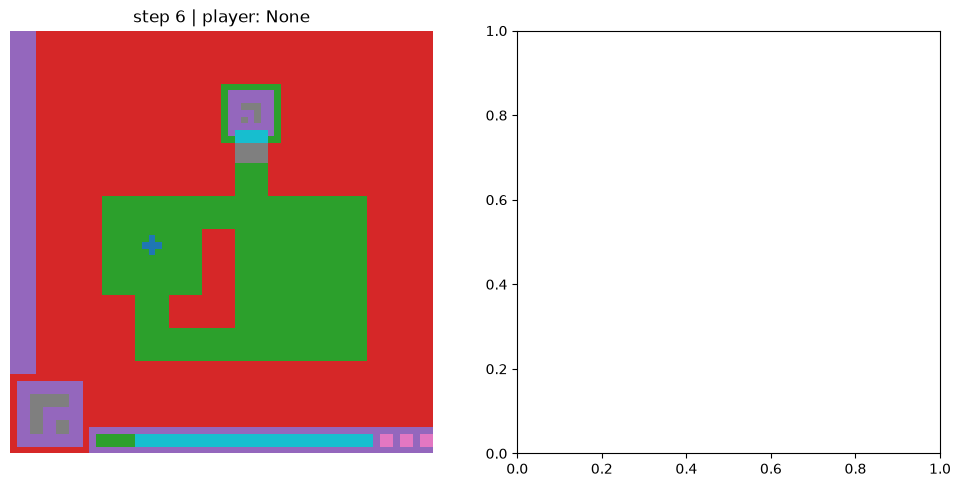

In [10]:
obs = env.reset()

for i in range(6):
    obs = env.step(ACTION_UP)

frame_before = np.array(obs.frame).squeeze()
obs = env.step(ACTION_UP)
frame_after = np.array(obs.frame).squeeze()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(frame_before, cmap="tab10", vmin=0, vmax=12)
axes[0].set_title(f"step 6 | player: {get_player_position({'frame': frame_before})}")
axes[0].axis("off")

axes[1].imshow(frame_after, cmap="tab10", vmin=0, vmax=12)
axes[1].set_title(f"step 7 | player: {get_player_position({'frame': frame_after})}")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("logs/ls20_teleport_analysis.png", dpi=100)
plt.show()

In [11]:
obs = env.reset()
for i in range(7):
    obs = env.step(ACTION_UP)

frame_raw = np.array(obs.frame)
print(f"frame shape: {frame_raw.shape}")
print(f"number of layers: {frame_raw.shape[0]}")

for i in range(frame_raw.shape[0]):
    layer = frame_raw[i]
    unique = np.unique(layer).tolist()
    print(f"layer {i}: shape {layer.shape} | unique colors: {unique}")

frame shape: (6, 64, 64)
number of layers: 6
layer 0: shape (64, 64) | unique colors: [0, 1, 3, 4, 5, 8, 9, 11, 12]
layer 1: shape (64, 64) | unique colors: [0, 1, 3, 4, 5, 8, 9, 11, 12]
layer 2: shape (64, 64) | unique colors: [0, 1, 3, 4, 5, 8, 9, 11, 12]
layer 3: shape (64, 64) | unique colors: [0, 1, 3, 4, 5, 8, 9, 11, 12]
layer 4: shape (64, 64) | unique colors: [0, 1, 3, 4, 5, 8, 9, 11, 12]
layer 5: shape (64, 64) | unique colors: [0, 1, 3, 4, 5, 8, 9, 11, 12]


frame shape: (6, 64, 64)
player position: [15.5 36. ]
goal position: [16.23809524 36.04761905]


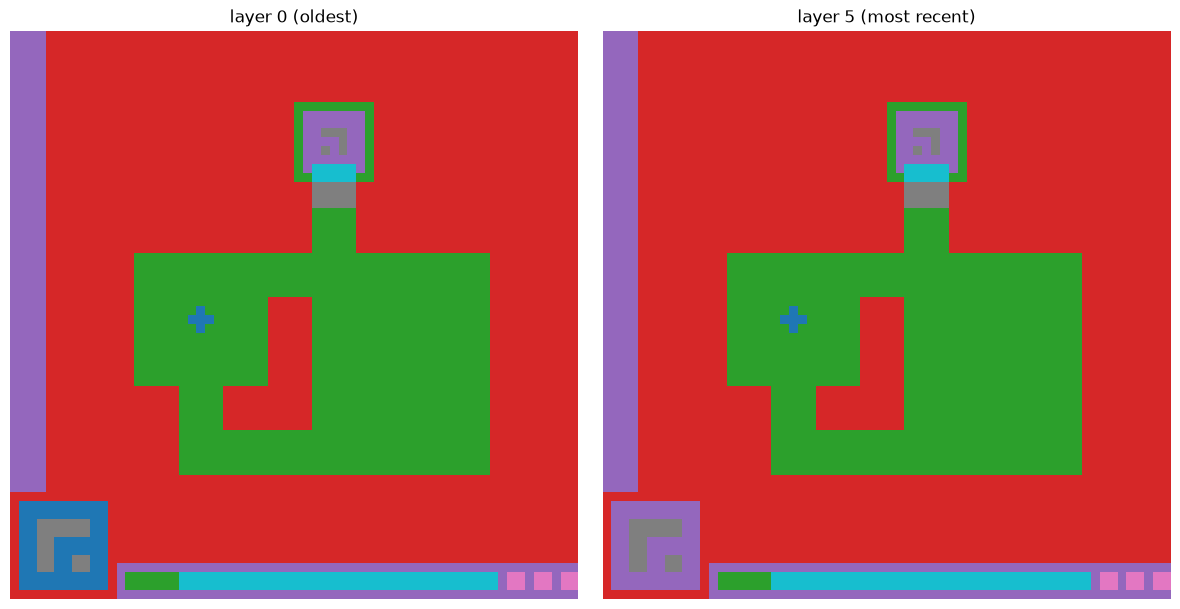

In [12]:
def get_frame(obs):
    frame = np.array(obs.frame)
    if frame.ndim == 3:
        return frame[-1]  # always use most recent layer
    return frame.squeeze()

def get_player_position(obs_or_frame):
    if hasattr(obs_or_frame, 'frame'):
        frame = get_frame(obs_or_frame)
    else:
        frame = np.array(obs_or_frame)
        if frame.ndim == 3:
            frame = frame[-1]
        else:
            frame = frame.squeeze()
    positions = np.argwhere(frame == 12)
    if len(positions) > 0:
        return positions.mean(axis=0)[:2]
    return None

def get_goal_position(obs_or_frame):
    if hasattr(obs_or_frame, 'frame'):
        frame = get_frame(obs_or_frame)
    else:
        frame = np.array(obs_or_frame)
        if frame.ndim == 3:
            frame = frame[-1]
        else:
            frame = frame.squeeze()
    positions = np.argwhere(frame == 9)
    if len(positions) > 0:
        top_half = positions[positions[:, 0] < 32]
        if len(top_half) > 0:
            return top_half.mean(axis=0)[:2]
    return None

# verify
obs = env.reset()
for i in range(7):
    obs = env.step(ACTION_UP)

print(f"frame shape: {np.array(obs.frame).shape}")
print(f"player position: {get_player_position(obs)}")
print(f"goal position: {get_goal_position(obs)}")

# visualize layer 0 and layer 5
frame_raw = np.array(obs.frame)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(frame_raw[0], cmap="tab10", vmin=0, vmax=12)
axes[0].set_title("layer 0 (oldest)")
axes[0].axis("off")
axes[1].imshow(frame_raw[-1], cmap="tab10", vmin=0, vmax=12)
axes[1].set_title("layer 5 (most recent)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("logs/ls20_multilayer_analysis.png", dpi=100)
plt.show()

In [13]:
frame = get_frame(obs)

print("all color 9 positions:")
positions = np.argwhere(frame == 9)
print(positions)

print("\nall color 12 positions:")
positions12 = np.argwhere(frame == 12)
print(positions12)

print("\nall color 5 positions (sample):")
positions5 = np.argwhere(frame == 5)
print(f"total: {len(positions5)} | first 10: {positions5[:10]}")

all color 9 positions:
[[11 35]
 [11 36]
 [11 37]
 [12 37]
 [13 35]
 [13 37]
 [17 34]
 [17 35]
 [17 36]
 [17 37]
 [17 38]
 [18 34]
 [18 35]
 [18 36]
 [18 37]
 [18 38]
 [19 34]
 [19 35]
 [19 36]
 [19 37]
 [19 38]
 [55  3]
 [55  4]
 [55  5]
 [55  6]
 [55  7]
 [55  8]
 [56  3]
 [56  4]
 [56  5]
 [56  6]
 [56  7]
 [56  8]
 [57  3]
 [57  4]
 [58  3]
 [58  4]
 [59  3]
 [59  4]
 [59  7]
 [59  8]
 [60  3]
 [60  4]
 [60  7]
 [60  8]]

all color 12 positions:
[[15 34]
 [15 35]
 [15 36]
 [15 37]
 [15 38]
 [16 34]
 [16 35]
 [16 36]
 [16 37]
 [16 38]]

all color 5 positions (sample):
total: 434 | first 10: [[0 0]
 [0 1]
 [0 2]
 [0 3]
 [1 0]
 [1 1]
 [1 2]
 [1 3]
 [2 0]
 [2 1]]


In [14]:
def get_goal_position(obs_or_frame):
    if hasattr(obs_or_frame, 'frame'):
        frame = get_frame(obs_or_frame)
    else:
        frame = np.array(obs_or_frame)
        if frame.ndim == 3:
            frame = frame[-1]
        else:
            frame = frame.squeeze()
    
    positions = np.argwhere(frame == 9)
    if len(positions) == 0:
        return None
    
    # only use color 9 pixels in top quarter of frame
    top_quarter = positions[positions[:, 0] < 16]
    if len(top_quarter) > 0:
        return top_quarter.mean(axis=0)[:2]
    return None

# verify
obs = env.reset()
for i in range(7):
    obs = env.step(ACTION_UP)

print(f"player: {get_player_position(obs)}")
print(f"goal: {get_goal_position(obs)}")

player: [15.5 36. ]
goal: [11.83333333 36.16666667]


In [15]:
obs = env.reset()
step = 0
max_steps = 500
blocked_actions = set()
prev_player = None
last_action = None

print("starting fixed agent")
print(f"player: {get_player_position(obs)}")
print(f"goal: {get_goal_position(obs)}")

while obs.state.value == "NOT_FINISHED" and step < max_steps:
    player = get_player_position(obs)
    goal = get_goal_position(obs)

    if player is None or goal is None:
        action = np.random.choice(obs.available_actions)
        blocked_actions = set()
    else:
        if prev_player is not None and np.allclose(player, prev_player, atol=1.0):
            blocked_actions.add(last_action)
        else:
            blocked_actions = set()

        action = choose_action(player, goal, blocked_actions, obs.available_actions)

    prev_player = player
    last_action = action
    obs = env.step(action)
    step += 1

    if step % 10 == 0:
        p = get_player_position(obs)
        g = get_goal_position(obs)
        print(f"step {step:03d} | levels: {obs.levels_completed} | player: {p} | goal: {g}")

print(f"\ngame ended after {step} steps")
print(f"final state: {obs.state.value}")
print(f"levels completed: {obs.levels_completed} / {obs.win_levels}")

starting fixed agent
player: [45.5 36. ]
goal: [11.83333333 36.16666667]
step 010 | levels: 0 | player: [20.5 36. ] | goal: [11.83333333 36.16666667]
step 020 | levels: 0 | player: [15.5 36. ] | goal: [11.83333333 36.16666667]
step 030 | levels: 0 | player: [15.5 36. ] | goal: [11.83333333 36.16666667]
step 040 | levels: 0 | player: [15.5 36. ] | goal: [11.83333333 36.16666667]
step 050 | levels: 0 | player: [15.5 36. ] | goal: [11.83333333 36.16666667]
step 060 | levels: 0 | player: [15.5 36. ] | goal: [11.83333333 36.16666667]
step 070 | levels: 0 | player: [15.5 36. ] | goal: [11.83333333 36.16666667]
step 080 | levels: 0 | player: [15.5 36. ] | goal: [11.83333333 36.16666667]
step 090 | levels: 0 | player: [15.5 36. ] | goal: [11.83333333 36.16666667]
step 100 | levels: 0 | player: [15.5 36. ] | goal: [11.83333333 36.16666667]
step 110 | levels: 0 | player: [35.5 36. ] | goal: [11.83333333 36.16666667]
step 120 | levels: 0 | player: [15.5 36. ] | goal: [11.83333333 36.16666667]
ste

In [16]:
obs = env.reset()

# get to row 15 first
for i in range(6):
    obs = env.step(ACTION_UP)

print(f"at row 15: player={get_player_position(obs)}")

# now try each action one at a time and report
for action_name, action in [("UP",1),("UP",1),("UP",1),("UP",1),("UP",1)]:
    prev = get_player_position(obs)
    obs = env.step(action)
    curr = get_player_position(obs)
    frame = get_frame(obs)
    color12 = np.argwhere(frame == 12).tolist()
    print(f"{action_name} | prev:{prev} -> curr:{curr} | color12 pixels:{color12}")

at row 15: player=[15.5 36. ]
UP | prev:[15.5 36. ] -> curr:[15.5 36. ] | color12 pixels:[[15, 34], [15, 35], [15, 36], [15, 37], [15, 38], [16, 34], [16, 35], [16, 36], [16, 37], [16, 38]]
UP | prev:[15.5 36. ] -> curr:[15.5 36. ] | color12 pixels:[[15, 34], [15, 35], [15, 36], [15, 37], [15, 38], [16, 34], [16, 35], [16, 36], [16, 37], [16, 38]]
UP | prev:[15.5 36. ] -> curr:[15.5 36. ] | color12 pixels:[[15, 34], [15, 35], [15, 36], [15, 37], [15, 38], [16, 34], [16, 35], [16, 36], [16, 37], [16, 38]]
UP | prev:[15.5 36. ] -> curr:[15.5 36. ] | color12 pixels:[[15, 34], [15, 35], [15, 36], [15, 37], [15, 38], [16, 34], [16, 35], [16, 36], [16, 37], [16, 38]]
UP | prev:[15.5 36. ] -> curr:[15.5 36. ] | color12 pixels:[[15, 34], [15, 35], [15, 36], [15, 37], [15, 38], [16, 34], [16, 35], [16, 36], [16, 37], [16, 38]]


In [17]:
# fresh run - press UP exactly 6 times and check frame
obs = env.reset()
for i in range(6):
    obs = env.step(ACTION_UP)

frame_6 = get_frame(obs)
print("after 6 UPs from reset:")
print(f"color 12 positions: {np.argwhere(frame_6 == 12).tolist()}")
print(f"color 9 positions (top): {np.argwhere(frame_6[:16, :] == 9).tolist()}")

# now press UP one more time
obs = env.step(ACTION_UP)
frame_7 = get_frame(obs)
print("\nafter 7th UP:")
print(f"player position: {get_player_position(obs)}")
print(f"color 12 positions: {np.argwhere(frame_7 == 12).tolist()}")
print(f"levels completed: {obs.levels_completed}")
print(f"state: {obs.state.value}")

after 6 UPs from reset:
color 12 positions: [[15, 34], [15, 35], [15, 36], [15, 37], [15, 38], [16, 34], [16, 35], [16, 36], [16, 37], [16, 38]]
color 9 positions (top): [[11, 35], [11, 36], [11, 37], [12, 37], [13, 35], [13, 37]]

after 7th UP:
player position: [15.5 36. ]
color 12 positions: [[15, 34], [15, 35], [15, 36], [15, 37], [15, 38], [16, 34], [16, 35], [16, 36], [16, 37], [16, 38]]
levels completed: 0
state: NOT_FINISHED


In [18]:
with open("environment_files/ls20/9607627b/ls20.py", "r") as f:
    lines = f.readlines()

print(f"total lines: {len(lines)}")

# search for key terms
keywords = ["GAME_OVER", "levels_completed", "win", "action", "player", "goal", "teleport", "reset", "ACTION1", "ACTION2"]

for keyword in keywords:
    matches = [(i+1, line.strip()) for i, line in enumerate(lines) if keyword.lower() in line.lower()]
    if matches:
        print(f"\n--- {keyword} ({len(matches)} matches) ---")
        for lineno, line in matches[:5]:
            print(f"  line {lineno}: {line}")

total lines: 2060

--- win (1 matches) ---
  line 10: # furnished to do so, subject to the following conditions:

--- action (14 matches) ---
  line 19: # LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
  line 31: GameAction,
  line 1787: super().__init__(game_id="ls20", levels=levels, camera=xngzmcbxu, available_actions=[1, 2, 3, 4])
  line 1920: self.complete_action()
  line 1928: self.complete_action()

--- goal (16 matches) ---
  line 740: "GoalColor": 9,
  line 741: "GoalRotation": 0,
  line 867: "GoalColor": 9,
  line 868: "GoalRotation": 270,
  line 979: "GoalColor": 9,

--- ACTION1 (1 matches) ---
  line 1943: if self.action.id == GameAction.ACTION1:

--- ACTION2 (1 matches) ---
  line 1946: elif self.action.id == GameAction.ACTION2:


In [19]:
for i, line in enumerate(lines[1935:1970], start=1936):
    print(f"line {i}: {line.rstrip()}")

line 1936:             for pidqulszaw in self.current_level.get_sprites_by_tag("hoswmpiqkw"):
line 1937:                 pidqulszaw.set_visible(False)
line 1938:             self.complete_action()
line 1939:             return
line 1940:         hnrvmfooc = 0
line 1941:         feyjbrwyb = 0
line 1942:         etvjlacrau = False
line 1943:         if self.action.id == GameAction.ACTION1:
line 1944:             feyjbrwyb = -1
line 1945:             etvjlacrau = True
line 1946:         elif self.action.id == GameAction.ACTION2:
line 1947:             feyjbrwyb = 1
line 1948:             etvjlacrau = True
line 1949:         elif self.action.id == GameAction.ACTION3:
line 1950:             hnrvmfooc = -1
line 1951:             etvjlacrau = True
line 1952:         elif self.action.id == GameAction.ACTION4:
line 1953:             hnrvmfooc = 1
line 1954:             etvjlacrau = True
line 1955:         if not etvjlacrau:
line 1956:             self.complete_action()
line 1957:             re

In [20]:
keywords2 = ["game_over", "level_complete", "levels_completed", "complete_action", "camera"]
for keyword in keywords2:
    matches = [(i+1, line.strip()) for i, line in enumerate(lines) if keyword.lower() in line.lower()]
    if matches:
        print(f"\n--- {keyword} ({len(matches)} matches) ---")
        for lineno, line in matches[:8]:
            print(f"  line {lineno}: {line}")


--- complete_action (7 matches) ---
  line 1920: self.complete_action()
  line 1928: self.complete_action()
  line 1938: self.complete_action()
  line 1956: self.complete_action()
  line 1980: self.complete_action()
  line 1986: self.complete_action()
  line 2014: self.complete_action()

--- camera (3 matches) ---
  line 30: Camera,
  line 1780: xngzmcbxu = Camera(
  line 1787: super().__init__(game_id="ls20", levels=levels, camera=xngzmcbxu, available_actions=[1, 2, 3, 4])


In [21]:
for i, line in enumerate(lines[1970:2015], start=1971):
    print(f"line {i}: {line.rstrip()}")

line 1971:             return
line 1972:         bkuguqrpvq = not yubyobdoss and (not self._step_counter_ui.mfyzdfvxsm())
line 1973:         if not bkuguqrpvq:
line 1974:             for shdkimnqse in self.hasivfwip:
line 1975:                 if shdkimnqse.prpxgfxlcm(self.gudziatsk):
line 1976:                     self.euemavvxz.append(shdkimnqse)
line 1977:                     return
line 1978:         if self.pbznecvnfr():
line 1979:             self.next_level()
line 1980:             self.complete_action()
line 1981:             return
line 1982:         if bkuguqrpvq:
line 1983:             self.aqygnziho -= 1
line 1984:             if self.aqygnziho == 0:
line 1985:                 self.lose()
line 1986:                 self.complete_action()
line 1987:                 return
line 1988:             self.aqdxgoyvu.set_visible(True)
line 1989:             self.aqdxgoyvu.set_scale(64)
line 1990:             self.aqdxgoyvu.set_position(0, 0)
line 1991:             self.htkmubhry.set

In [22]:
matches = [(i+1, line.strip()) for i, line in enumerate(lines) if "pbznecvnfr" in line]
print(f"pbznecvnfr appears {len(matches)} times:")
for lineno, line in matches[:10]:
    print(f"  line {lineno}: {line}")

pbznecvnfr appears 2 times:
  line 1978: if self.pbznecvnfr():
  line 2042: def pbznecvnfr(self) -> bool:


In [23]:
for i, line in enumerate(lines[2041:2060], start=2042):
    print(f"line {i}: {line.rstrip()}")

line 2042:     def pbznecvnfr(self) -> bool:
line 2043:         for i, spssohsnbq in enumerate(self.plrpelhym):
line 2044:             if not self.lvrnuajbl[i] and self.gudziatsk.x == spssohsnbq.x and (self.gudziatsk.y == spssohsnbq.y) and self.bejndxqqzf(i):
line 2045:                 self.lvrnuajbl[i] = True
line 2046:                 self.byotxmvkt.append(self.plrpelhym[i])
line 2047:                 self.alsxlhizr.append(self.srgbthxut[i])
line 2048:                 self.current_level.remove_sprite(self.plrpelhym[i])
line 2049:                 self.current_level.remove_sprite(self.srgbthxut[i])
line 2050:                 opdsmckaqo = self.current_level.get_sprite_at(spssohsnbq.x - 1, spssohsnbq.y - 1, "vjotnebuqo")
line 2051:                 if opdsmckaqo and "vfkkzdgxzx" in opdsmckaqo.tags:
line 2052:                     opdsmckaqo.set_visible(False)
line 2053:                     pidqulszaw = self.current_level.get_sprite_at(spssohsnbq.x - 1, spssohsnbq.y - 1, "hoswmpiqkw")
line 

In [24]:
matches = [(i+1, line.strip()) for i, line in enumerate(lines) if "plrpelhym" in line]
print(f"plrpelhym appears {len(matches)} times:")
for lineno, line in matches[:15]:
    print(f"  line {lineno}: {line}")

plrpelhym appears 8 times:
  line 1811: self.plrpelhym = self.current_level.get_sprites_by_tag("rjlbuycveu")
  line 1833: for dinyecvyq in range(len(self.plrpelhym)):
  line 1883: wyhfvzxukh = self.plrpelhym.index(mvcsnkcqz)
  line 1993: self.lvrnuajbl = [False] * len(self.plrpelhym)
  line 2028: for wyhfvzxukh, spssohsnbq in enumerate(self.plrpelhym):
  line 2043: for i, spssohsnbq in enumerate(self.plrpelhym):
  line 2046: self.byotxmvkt.append(self.plrpelhym[i])
  line 2048: self.current_level.remove_sprite(self.plrpelhym[i])


In [25]:
matches = [(i+1, line.strip()) for i, line in enumerate(lines) if "bejndxqqzf" in line]
print(f"bejndxqqzf appears {len(matches)} times:")
for lineno, line in matches[:10]:
    print(f"  line {lineno}: {line}")

# also look at lines 1825-1895 to understand level initialization
print("\n--- level initialization (lines 1825-1895) ---")
for i, line in enumerate(lines[1824:1895], start=1825):
    if line.strip():
        print(f"line {i}: {line.rstrip()}")

bejndxqqzf appears 4 times:
  line 1884: if not self.bejndxqqzf(wyhfvzxukh):
  line 2030: if self.bejndxqqzf(wyhfvzxukh) and (not self.lvrnuajbl[wyhfvzxukh]):
  line 2039: def bejndxqqzf(self, wyhfvzxukh: int) -> bool:
  line 2044: if not self.lvrnuajbl[i] and self.gudziatsk.x == spssohsnbq.x and (self.gudziatsk.y == spssohsnbq.y) and self.bejndxqqzf(i):

--- level initialization (lines 1825-1895) ---
line 1825:         if isinstance(self.ldxlnycps, int):
line 1826:             self.ldxlnycps = [self.ldxlnycps]
line 1827:         ldgzgjdsrf = self.current_level.get_data("GoalRotation")
line 1828:         if isinstance(ldgzgjdsrf, int):
line 1829:             ldgzgjdsrf = [ldgzgjdsrf]
line 1830:         lbgtuaplev = self.current_level.get_data("GoalColor")
line 1831:         if isinstance(lbgtuaplev, int):
line 1832:             lbgtuaplev = [lbgtuaplev]
line 1833:         for dinyecvyq in range(len(self.plrpelhym)):
line 1834:             self.ehwheiwsk.append(self.dhksvilbb.index(ldgz

In [26]:
for i, line in enumerate(lines[2038:2060], start=2039):
    print(f"line {i}: {line.rstrip()}")

line 2039:     def bejndxqqzf(self, wyhfvzxukh: int) -> bool:
line 2040:         return self.fwckfzsyc == self.ldxlnycps[wyhfvzxukh] and self.hiaauhahz == self.yjdexjsoa[wyhfvzxukh] and (self.cklxociuu == self.ehwheiwsk[wyhfvzxukh])
line 2041: 
line 2042:     def pbznecvnfr(self) -> bool:
line 2043:         for i, spssohsnbq in enumerate(self.plrpelhym):
line 2044:             if not self.lvrnuajbl[i] and self.gudziatsk.x == spssohsnbq.x and (self.gudziatsk.y == spssohsnbq.y) and self.bejndxqqzf(i):
line 2045:                 self.lvrnuajbl[i] = True
line 2046:                 self.byotxmvkt.append(self.plrpelhym[i])
line 2047:                 self.alsxlhizr.append(self.srgbthxut[i])
line 2048:                 self.current_level.remove_sprite(self.plrpelhym[i])
line 2049:                 self.current_level.remove_sprite(self.srgbthxut[i])
line 2050:                 opdsmckaqo = self.current_level.get_sprite_at(spssohsnbq.x - 1, spssohsnbq.y - 1, "vjotnebuqo")
line 2051:                